# Objective

The objective of this analysis is to investigate the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using historical trading data from Hyperliquid. By combining both datasets, the analysis aims to identify patterns in profitability, trading behavior, and market sentiment that can provide actionable insights for improving trading strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [9]:
trader_df = pd.read_csv("historical_data (1).csv")
sentiment_df = pd.read_csv("fear_greed_index (1).csv")

In [11]:
print("Trader Dataset")
display(trader_df.head())

print("\nSentiment Dataset")
display(sentiment_df.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [13]:
print("Trader Dataset Shape:", trader_df.shape)
print("Sentiment Dataset Shape:", sentiment_df.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [15]:
print(trader_df.columns)

print(sentiment_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [17]:
trader_df.info()

sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [19]:
print(trader_df.isnull().sum())

print(sentiment_df.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [21]:
print("Trader duplicates:", trader_df.duplicated().sum())

print("Sentiment duplicates:", sentiment_df.duplicated().sum())

Trader duplicates: 0
Sentiment duplicates: 0


In [25]:
trader_df["Timestamp IST"] = pd.to_datetime(
    trader_df["Timestamp IST"],
    dayfirst=True
)

In [27]:
trader_df["Timestamp IST"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]

In [29]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

In [33]:
sentiment_df["date"].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]

In [35]:
trader_df["Date"] = trader_df["Timestamp IST"].dt.date
sentiment_df["Date"] = sentiment_df["date"].dt.date

In [37]:
print("Trader Data:")
print(trader_df["Date"].min(), "to", trader_df["Date"].max())

print("\nSentiment Data:")
print(sentiment_df["Date"].min(), "to", sentiment_df["Date"].max())

Trader Data:
2023-05-01 to 2025-05-01

Sentiment Data:
2018-02-01 to 2025-05-02


In [39]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [41]:
print("Merged Dataset Shape:", merged_df.shape)
print("Missing Sentiment Values:", merged_df["classification"].isna().sum())

merged_df.head()

Merged Dataset Shape: (211224, 19)
Missing Sentiment Values: 6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [43]:
merged_df = merged_df.dropna(subset=["classification"])

In [45]:
merged_df["classification"].isna().sum()

0

In [ ]:
# Exploratory Data Analysis (EDA)

#This section explores trader behavior and performance under different Bitcoin market sentiment conditions (Fear & Greed Index).

In [47]:
print("Total Trades:", len(merged_df))
print("Unique Traders:", merged_df["Account"].nunique())
print("Coins Traded:", merged_df["Coin"].nunique())
print("Unique Coins:", merged_df["Coin"].unique())

Total Trades: 211218
Unique Traders: 32
Coins Traded: 246
Unique Coins: ['@107' 'AAVE' 'DYDX' 'AIXBT' 'GMX' 'EIGEN' 'HYPE' 'SOL' 'SUI' 'DOGE'
 'ETH' 'kPEPE' 'TRUMP' 'ONDO' 'ENA' 'LINK' 'XRP' 'S' 'BNB' 'BERA' 'WIF'
 'LAYER' 'MKR' 'KAITO' 'IP' 'JUP' 'USUAL' 'ADA' 'BTC' 'PURR/USDC' 'ZRO'
 '@7' '@19' '@21' '@44' '@48' '@11' '@15' '@46' '@61' '@28' '@45' '@9'
 '@41' '@38' 'kSHIB' 'GRASS' 'TAO' 'AVAX' '@2' '@6' '@8' '@10' '@12' '@16'
 '@17' '@35' '@26' '@24' '@32' '@29' '@31' '@33' '@34' '@36' '@37' '@47'
 '@53' '@74' 'RUNE' 'CANTO' 'NTRN' 'BLUR' 'ZETA' 'MINA' 'MANTA' 'RNDR'
 'WLD' 'kBONK' 'ALT' 'INJ' 'STG' 'ZEN' 'MAVIA' 'PIXEL' 'ILV' 'FET' 'STRK'
 'CAKE' 'STX' 'ACE' 'PENDLE' 'AR' 'XAI' 'APE' 'MEME' 'NEAR' 'SEI' 'FTM'
 'MYRO' 'BIGTIME' 'IMX' 'BADGER' 'POLYX' 'OP' 'TNSR' 'MAV' 'TIA' 'MERL'
 'TON' 'PURR' 'ME' 'CRV' 'BRETT' 'CHILLGUY' 'MOODENG' 'VIRTUAL' 'COMP'
 'FARTCOIN' 'AI16Z' 'GRIFFAIN' 'ZEREBRO' 'SPX' 'MELANIA' 'PENGU' 'JELLY'
 'VVV' 'VINE' 'TST' 'ARK' 'YGG' 'POPCAT' 'NIL' 'MOVE' 'BABY' '

In [49]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724569344,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,21.012784


In [51]:
sentiment_counts = merged_df["classification"].value_counts()
print(sentiment_counts)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


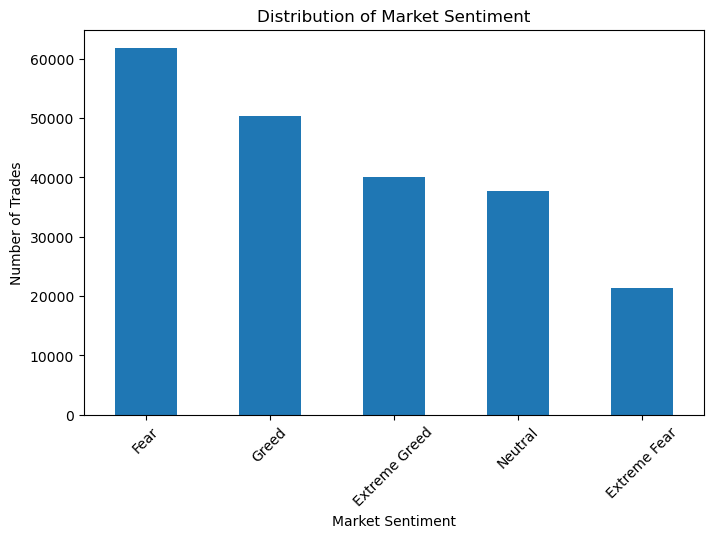

In [53]:
plt.figure(figsize=(8,5))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

In [55]:
profit_by_sentiment = merged_df.groupby("classification")["Closed PnL"].agg(
    ["count", "mean", "median", "sum"]
)

profit_by_sentiment

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06


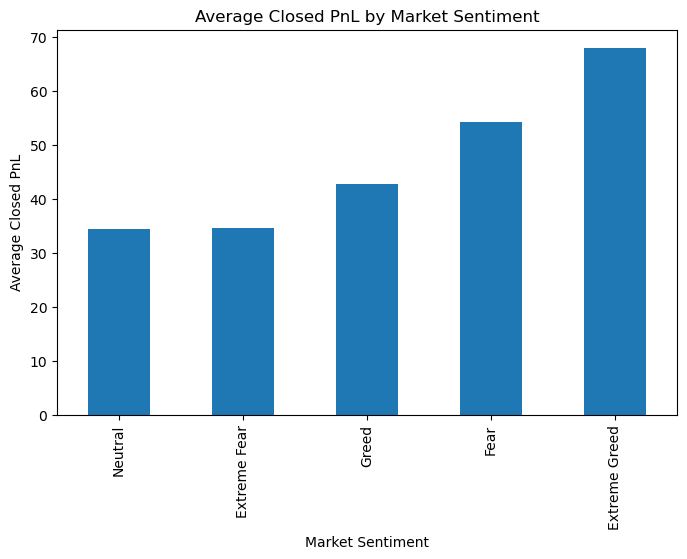

In [57]:
plt.figure(figsize=(8,5))

profit_by_sentiment["mean"].sort_values().plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [59]:
print("Number of Unique Coins:", merged_df["Coin"].nunique())

Number of Unique Coins: 246


### Insight

- Fear was the most common market sentiment during the trading period.
- Extreme Fear occurred least frequently.
- Trading activity was concentrated during Fear and Greed market conditions.
- This suggests that traders were more active during emotionally driven market phases.
  

In [61]:
merged_df["Winning Trade"] = merged_df["Closed PnL"] > 0

In [63]:
win_rate = (
    merged_df.groupby("classification")["Winning Trade"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(win_rate)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Winning Trade, dtype: float64


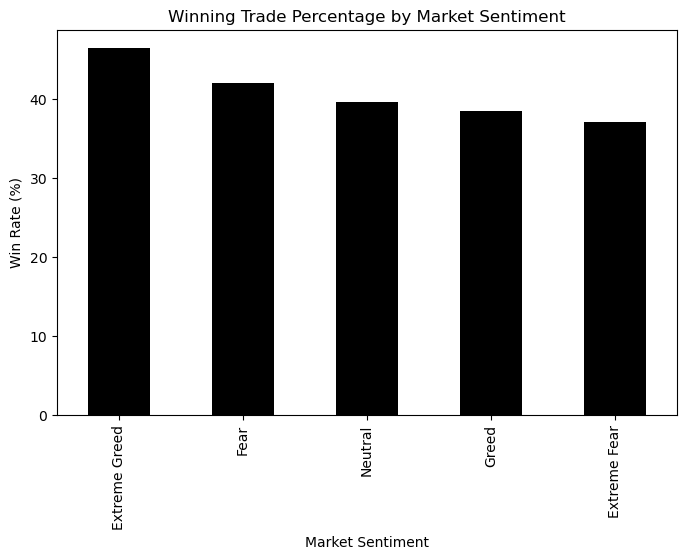

In [97]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar", color = 'black')

plt.title("Winning Trade Percentage by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [67]:
buy_sell = merged_df.groupby(["classification", "Side"])["Closed PnL"].mean().unstack()

buy_sell

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


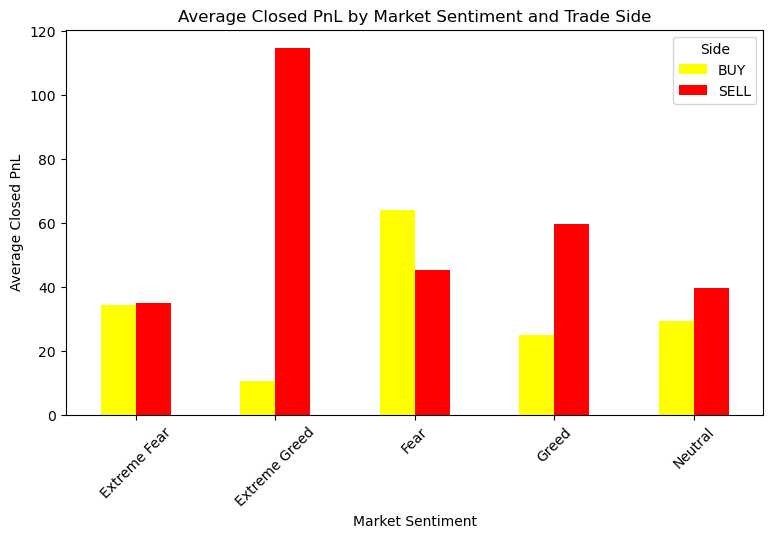

In [95]:
buy_sell.plot(kind="bar", figsize=(9,5) , color= ['yellow','red'])

plt.title("Average Closed PnL by Market Sentiment and Trade Side")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [71]:
top_coins = (
    merged_df.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_coins

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

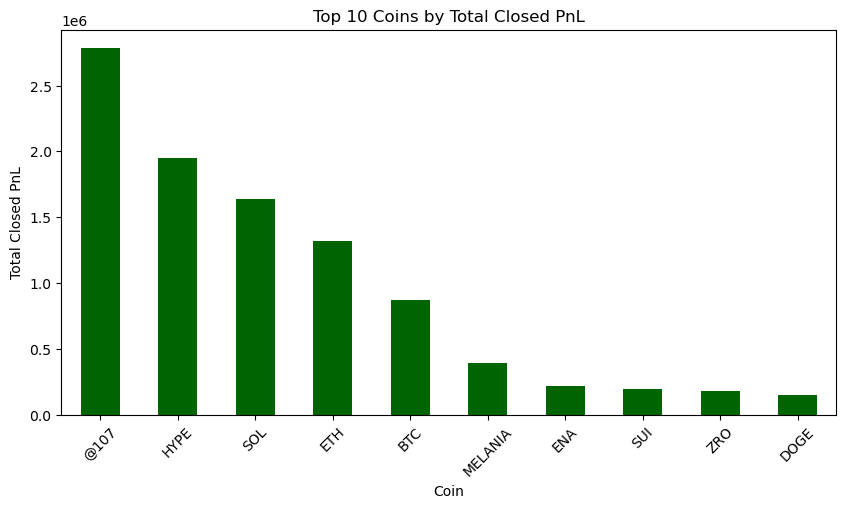

In [83]:
plt.figure(figsize=(10,5))

top_coins.plot(kind="bar", color = 'darkgreen')

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [75]:
top_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

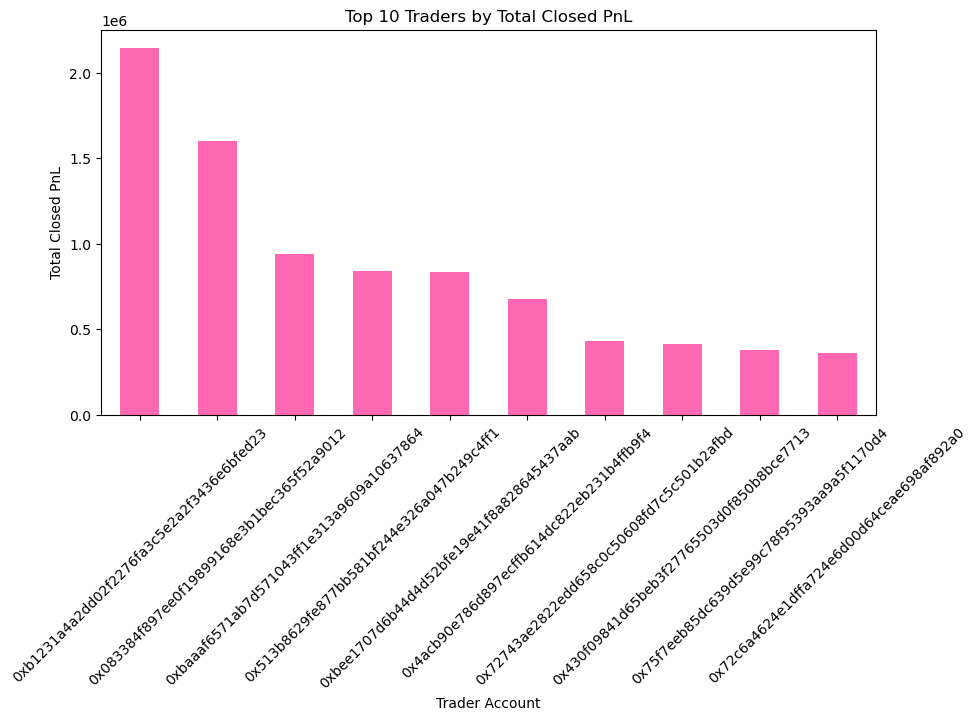

In [81]:
plt.figure(figsize=(10,5))

top_traders.plot(kind="bar", color = 'hotpink')

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

# Key Insights

1. Fear was the most frequently observed market sentiment, indicating increased trading activity during uncertain market conditions.

2. Trades executed during Extreme Greed generated the highest average Closed PnL, suggesting stronger profitability during bullish market phases.

3. Buy and Sell trades performed differently across market sentiments, highlighting that trade direction influences profitability depending on market conditions.

4. Trading activity was concentrated among a limited number of cryptocurrencies, with a few coins contributing significantly to total trading volume.

5. Trader performance varied considerably, with a small number of traders accounting for a large share of overall profits.

6. The analysis indicates a measurable relationship between Bitcoin market sentiment and trader performance, suggesting that sentiment indicators can support trading strategy development.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and historical trader performance by combining the Fear & Greed Index with Hyperliquid trading data.

The findings indicate that market sentiment has a noticeable impact on trader profitability. Periods of Extreme Greed were associated with the highest average profits, while Fear dominated the trading activity. Differences in Buy and Sell performance across sentiment categories further suggest that traders react differently under varying market conditions.

Overall, incorporating market sentiment into trading decisions may help improve strategy design, risk management, and timing of trades.